In [ ]:
# import the libs which needed
import torch
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.optim
from torch import nn
import torchvision.transforms

In [ ]:
# create dataset from FashionMnist
train_dataset = FashionMNIST(root = "dataset/train", download=True , transform=transforms.ToTensor()  , train=True)
test_dataset = FashionMNIST(root = "dataset/test", download=True , transform= transforms.ToTensor() , train = False)
# create labels array
labels = train_dataset.classes

In [ ]:
# create train/testLoader and get itrator from each one
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True ,num_workers=4, pin_memory=True)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False , num_workers=4 , pin_memory=True)

trainIter = iter(trainloader)
train_img , train_label = next(trainIter)

testIter = iter(testloader)
test_img , test_label = next(testIter)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# print shapes to help us in build model arc
print(train_img.shape)
print(train_img[0].shape)
print(train_label.shape)

torch.Size([64, 1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([64])


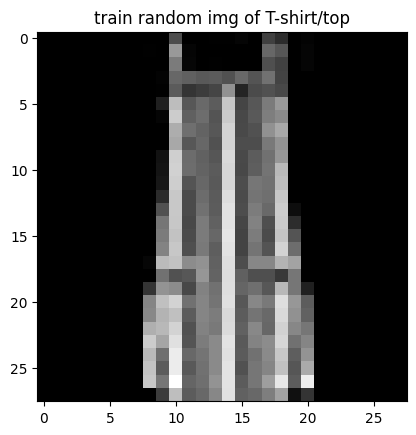

In [ ]:
# plt random img
plt.imshow(train_img[0].squeeze(), cmap="gray")
plt.title(f"train random img of {labels[0]}")
plt.show()

In [ ]:
# create model arc
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.cv1 = nn.Conv2d(1 , 64 , 3 , padding=1)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu1 = nn.ReLU()
    self.mp1 = nn.MaxPool2d(2)

    self.cv2 = nn.Conv2d(64 , 128 , 3 , padding = 1)
    self.bn2 = nn.BatchNorm2d(128)
    self.relu2 = nn.ReLU()
    self.mp2 = nn.MaxPool2d(2)

    self.cv3 = nn.Conv2d(128 , 256 , 3 , padding = 1)
    self.bn3 = nn.BatchNorm2d(256)
    self.relu3 = nn.ReLU()

    self.flatten = nn.Flatten()
    self.ln = nn.Linear(256*7*7 , 256)
    self.relu4 = nn.ReLU()
    self.dropout = nn.Dropout(p = 0.5)
    self.ln2 = nn.Linear(256 , 10)
  def forward(self , x):
    x = self.cv1(x)
    x = self.bn1(x)
    x = self.relu1(x)
    x = self.mp1(x)

    x = self.cv2(x)
    x = self.bn2(x)
    x = self.relu2(x)
    x = self.mp2(x)

    x = self.cv3(x)
    x = self.bn3(x)
    x = self.relu3(x)


    x = self.flatten(x)
    x = self.ln(x)
    x = self.relu4(x)
    x = self.dropout(x)
    x = self.ln2(x)
    return x

In [ ]:
# create model , loss function and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model()
model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
# function to evaluate model with accuracy
def evaluate(model , dataloader):
  was_training = model.training
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for img , label in dataloader:
      img = img.to(device)
      label = label.to(device)
      output = model(img)
      _ , preds = torch.max(output , dim=1)

      correct += (preds == label).sum().item()
      total += label.size(0)
  acc = correct/total
  if was_training:
        model.train()
  return acc

In [ ]:
# training and testing the model
epochs = 10
for epoch in range(epochs):
  model.train()
  current_epoch_loss = 0.0
  total = 0
  correct_train = 0
  for img , label in trainloader:
    img = img.to(device)
    label = label.to(device)
    predict = model(img)
    loss = loss_fn(predict , label)
    current_epoch_loss += loss.item() *label.size(0)
    total += label.size(0)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    _ , preds = torch.max(predict , dim=1)
    correct_train += (preds == label).sum().item()

  epoch_loss = current_epoch_loss / total
  train_acc = correct_train / total
  test_acc = evaluate(model, testloader)
  print(f"Epoch {epoch+1}: loss={epoch_loss:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

Epoch 1: loss=0.4700, train_acc=0.8358, test_acc=0.8909
Epoch 2: loss=0.3102, train_acc=0.8891, test_acc=0.8914
Epoch 3: loss=0.2620, train_acc=0.9058, test_acc=0.9148
Epoch 4: loss=0.2283, train_acc=0.9168, test_acc=0.9093
Epoch 5: loss=0.2009, train_acc=0.9284, test_acc=0.9187
Epoch 6: loss=0.1749, train_acc=0.9369, test_acc=0.9238
Epoch 7: loss=0.1544, train_acc=0.9434, test_acc=0.9245
Epoch 8: loss=0.1378, train_acc=0.9489, test_acc=0.9234
Epoch 9: loss=0.1191, train_acc=0.9559, test_acc=0.9276
Epoch 10: loss=0.1011, train_acc=0.9631, test_acc=0.9242


<function matplotlib.pyplot.show(close=None, block=None)>

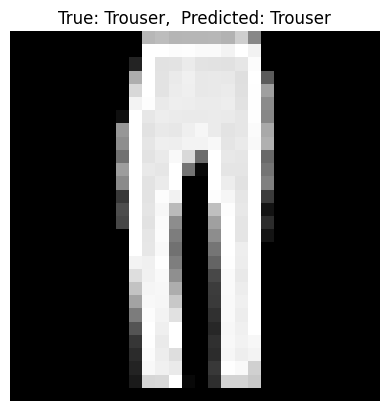

In [ ]:
# plt random img with the real class and predicted class
rand_test_img , rand_test_label = next(testIter)
img = rand_test_img[0].unsqueeze(0)
label = rand_test_label[0]

_ , predict = torch.max(model(img.to(device)) , dim=1)

plt.imshow(img.squeeze() , cmap="gray")

plt.title(f"True: {labels[label]},  Predicted: {labels[predict.item()]}")
plt.axis(False)
plt.show